
# Davis Club

Davis Southern Club Women

Shows how to make unipartite projections of the graph and compute the
properties of those graphs.

These data were collected by Davis et al. in the 1930s.
They represent observed attendance at 14 social events by 18 Southern women.
The graph is bipartite (clubs, women).


In [14]:
import matplotlib.pyplot as plt
import networkx as nx
from networkx.algorithms import bipartite

G = nx.davis_southern_women_graph()
women = G.graph["top"]
clubs = G.graph["bottom"]

print("Number of women:", len(women))
print("Number of events:", len(events))
print("Total edges:", G.number_of_edges())


Number of women: 18
Number of events: 14
Total edges: 89


- This loads the Southern Women dataset as a bipartite graph. One set of nodes represents the women, and the other set represents the social events they attended.
- The dataset contains 18 women, 14 events, and 89 attendance links. Each edge represents one woman attending one event.

In [15]:
print("Biadjacency matrix")
print(bipartite.biadjacency_matrix(G, women, clubs))

Biadjacency matrix
  (0, 0)	1
  (0, 1)	1
  (0, 2)	1
  (0, 3)	1
  (0, 4)	1
  (0, 5)	1
  (0, 7)	1
  (0, 8)	1
  (1, 0)	1
  (1, 1)	1
  (1, 2)	1
  (1, 4)	1
  (1, 5)	1
  (1, 6)	1
  (1, 7)	1
  (2, 1)	1
  (2, 2)	1
  (2, 3)	1
  (2, 4)	1
  (2, 5)	1
  (2, 6)	1
  (2, 7)	1
  (2, 8)	1
  (3, 0)	1
  (3, 2)	1
  :	:
  (12, 7)	1
  (12, 8)	1
  (12, 9)	1
  (12, 11)	1
  (12, 12)	1
  (12, 13)	1
  (13, 5)	1
  (13, 6)	1
  (13, 8)	1
  (13, 9)	1
  (13, 10)	1
  (13, 11)	1
  (13, 12)	1
  (13, 13)	1
  (14, 6)	1
  (14, 7)	1
  (14, 9)	1
  (14, 10)	1
  (14, 11)	1
  (15, 7)	1
  (15, 8)	1
  (16, 8)	1
  (16, 10)	1
  (17, 8)	1
  (17, 10)	1


The biadjacency matrix shows which women attended which events. A value of 1 indicates attendance, so this matrix is the basic representation of the two-mode network.

In [16]:
# project bipartite graph onto women nodes
W = bipartite.projected_graph(G, women)
print()
print("#Friends, Member")
for w in women:
    print(f"{W.degree(w)} {w}")


#Friends, Member
17 Evelyn Jefferson
15 Laura Mandeville
17 Theresa Anderson
15 Brenda Rogers
11 Charlotte McDowd
15 Frances Anderson
15 Eleanor Nye
16 Pearl Oglethorpe
17 Ruth DeSand
17 Verne Sanderson
16 Myra Liddel
16 Katherina Rogers
17 Sylvia Avondale
17 Nora Fayette
17 Helen Lloyd
16 Dorothy Murchison
12 Olivia Carleton
12 Flora Price


This projection connects two women if they attended at least one event together. 
- The degree shows how many other women each person is connected to through shared event attendance. Since many women have high degree values, the women’s social network appears to be very dense and highly connected.
- Women such as Evelyn Jefferson, Theresa Anderson, Ruth DeSand, Sylvia Avondale, Nora Fayette, and Helen Lloyd are connected to nearly everyone else, while Olivia Carleton and Flora Price are less connected and appear more peripheral.

In [18]:
# project bipartite graph onto women nodes keeping number of co-occurrence
# the degree computed is weighted and counts the total number of shared contacts
W = bipartite.weighted_projected_graph(G, women)
print()
print("#Friend meetings, Member")
for w in women:
    print(f"{W.degree(w, weight='weight')} {w}")


#Friend meetings, Member
50 Evelyn Jefferson
45 Laura Mandeville
57 Theresa Anderson
46 Brenda Rogers
24 Charlotte McDowd
32 Frances Anderson
36 Eleanor Nye
31 Pearl Oglethorpe
40 Ruth DeSand
38 Verne Sanderson
33 Myra Liddel
37 Katherina Rogers
46 Sylvia Avondale
43 Nora Fayette
34 Helen Lloyd
24 Dorothy Murchison
14 Olivia Carleton
14 Flora Price


This weighted projection shows not just whether women are connected, but how often they are connected through shared events.
- Higher weighted degree means stronger overall overlap with others.
- Theresa Anderson and Evelyn Jefferson have especially high values, suggesting they are among the most central and socially active women in the network.

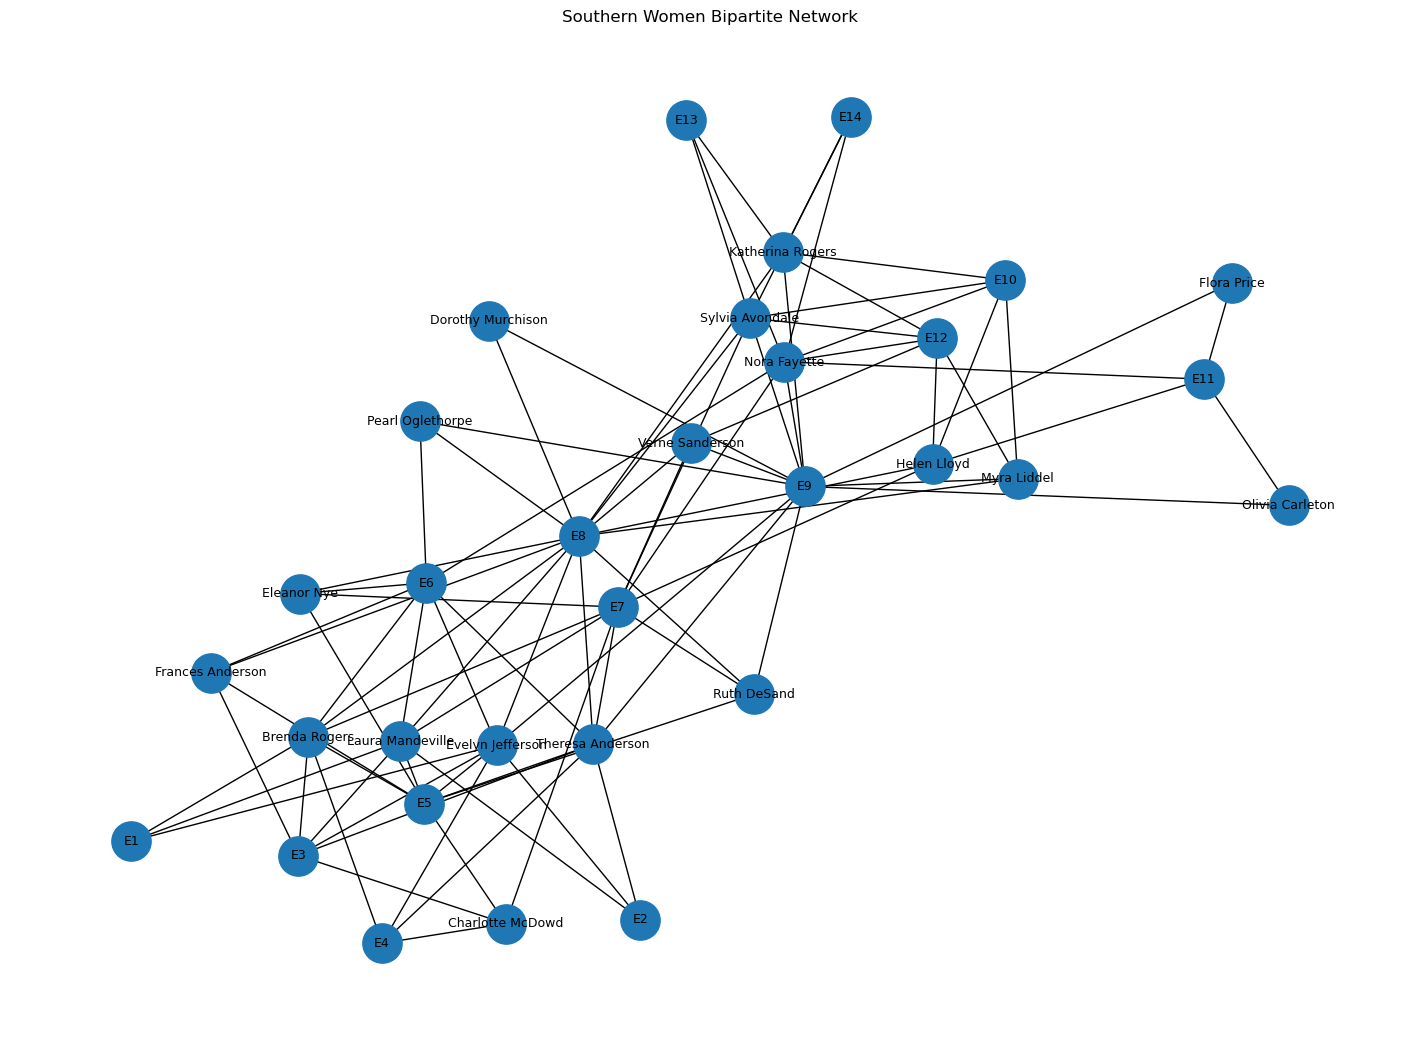

In [19]:
plt.figure(figsize=(14,10))

pos = nx.spring_layout(G, seed=648)
nx.draw(G, pos, with_labels=True, node_size=800, font_size=9)

plt.title("Southern Women Bipartite Network")
plt.show()

The network plot visually shows how women and events are connected. The graph suggests a tightly linked structure, with several events and women near the center, indicating substantial overlap in attendance patterns.

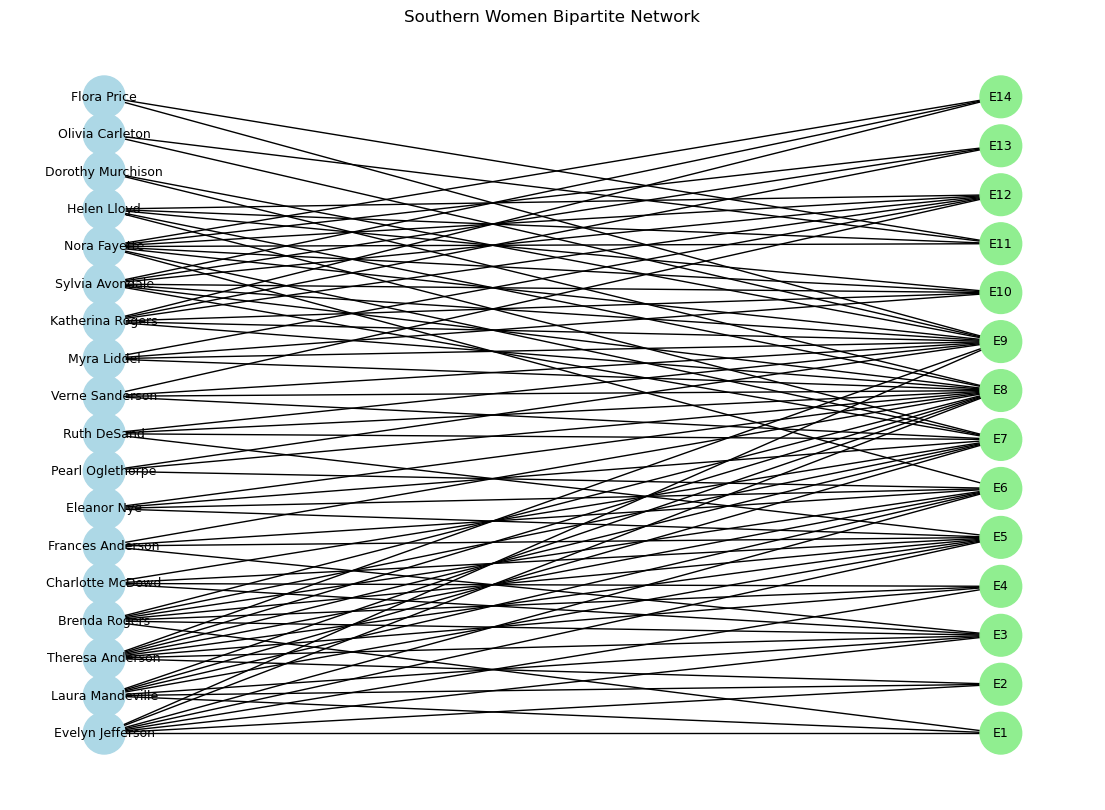

In [11]:
plt.figure(figsize=(14,10))

pos = nx.bipartite_layout(G, women)

nx.draw_networkx(G, pos,
                 node_color=["lightblue" if n in women else "lightgreen" for n in G.nodes()],
                 node_size=900,
                 font_size=9)

plt.title("Southern Women Bipartite Network")
plt.axis("off")
plt.show()

In the graph above, the blue nodes represent the women and the green nodes represent the social events. An edge connects a woman to an event if she attended that event.

The layout clearly separates the two node types, making it easy to see how women are connected through shared attendance at events. Many women attend multiple events, which creates overlapping participation across the network. Some events, such as E6, E7, E8, and E9, appear to have many connections, suggesting they were central social gatherings attended by many members of the group.

Overall, the visualization highlights how shared participation in events creates strong connections between individuals and forms the structure of the social network.

In [8]:
E = bipartite.weighted_projected_graph(G, events)

print("#Shared attendees, Event")
for e in events:
    print(f"{E.degree(e, weight='weight')} {e}")

#Shared attendees, Event
19 E1
20 E2
32 E3
23 E4
38 E5
41 E6
48 E7
59 E8
46 E9
25 E10
13 E11
28 E12
18 E13
18 E14


This projection connects two events if they share attendees.
- A higher weighted degree means an event shares more women with other events.
- Events like E8, E7, E9, and E6 appear to be the most central, which suggests they were major gatherings attended by many of the same women.
- Events such as E11, E13, and E14 have lower shared-attendance values, so they seem more specialized or less central.

## Relationships Between the Women

Most women are connected to nearly all other women (many have 15–17 connections out of 17 possible), which indicates that they frequently attended the same social events. This suggests that there is a tightly integrated social circle with strong overlap in participation.
- The weighted projection further shows differences in tie strength. For example, Theresa Anderson (57 shared meetings) and Evelyn Jefferson (50 shared meetings) have the highest total co-attendance counts, indicating they are central figures in the network. These women likely act as social hubs, strengthening the group cohesion.
- On the other hand, Olivia Carleton and Flora Price have much lower weighted degrees (14), suggesting they attended fewer shared events and may be less connected members of the social group.
- Overall, the women’s network appears to have a strong core with a few less embedded members.

## Relationships Between the Social Events

The projected events network shows variation in how strongly events are connected through shared attendees. 
- Events such as E8 (59 shared attendees), E7 (48 shared attendees), E6 (41 shared attendees), and E9 (46 shared attendees) have high weighted degrees, meaning many of the same women attended these events.
    - These likely represent major gatherings that brought together most of the group.
- On the other hand, events such as E11 (13 shared attendees), E13 (18 shared attendees), and E14 (18 shared attendees) have much lower shared attendance, suggesting they were smaller or attended by more specific subgroups.
    - This indicates that some events functioned as central social hubs, while others may have catered to smaller clusters within the network.

## Overall

The network suggests a highly connected social group of women, largely driven by their shared attendance at several key events. A few women and events appear to act as central hubs that connect much of the group. At the same time, some women attended fewer events and a few gatherings had smaller participation, which hints at smaller subgroups or social clusters within an otherwise closely connected social circle.